In [14]:
import StableRNGs: StableRNG
rng = StableRNG(318)
t = sort(10 .* rand(rng, 100))
u = sin.(t) .+ 0.5 * randn(rng, 100);

In [15]:
using DataInterpolations, Plots
using RegularizationTools


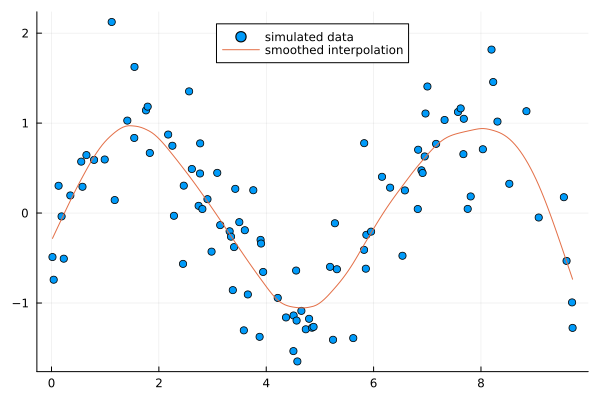

In [16]:
d = 2
A = RegularizationSmooth(u, t, d; alg=:gcv_svd)
û = A.û
N = 200
titp = collect(range(minimum(t), maximum(t), length=N))
uitp = A.(titp)
Am = RegularizationSmooth(u, t, titp, d; alg=:gcv_svd)
ûm = Am.û
scatter(t, u, label="simulated data", legend=:top)
#scatter!(t, û, marker=(:square, 4), label="smoothed data")
plot!(titp, uitp, label="smoothed interpolation")
#plot!(titp, ûm, linestyle=:dash, label="smoothed, more points")